In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

### Inspection 

In [2]:
df = pd.read_csv('../additional_material/datasets/week10/happy.csv')
df.sample(10)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
106,107,Ivory Coast,4.671,0.541,0.872,0.080,0.467,0.146,0.103
79,80,Lebanon,5.358,0.965,1.179,0.785,0.503,0.214,0.136
41,42,Poland,6.123,1.176,1.448,0.781,0.546,0.108,0.064
31,32,Qatar,6.374,1.649,1.303,0.748,0.654,0.256,0.171
122,123,Mozambique,4.417,0.198,0.902,0.173,0.531,0.206,0.158
12,13,Costa Rica,7.072,1.010,1.459,0.817,0.632,0.143,0.101
115,116,Sri Lanka,4.471,0.918,1.314,0.672,0.585,0.307,0.050
71,72,Honduras,5.504,0.620,1.205,0.622,0.459,0.197,0.074
111,112,Albania,4.586,0.916,0.817,0.790,0.419,0.149,0.032
39,40,El Salvador,6.167,0.806,1.231,0.639,0.461,0.065,0.082


In [22]:
df.isna().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
#renaming the clumns
df = df.rename(columns={
    "Overall rank": "overall_rank",
    "Country or region": "country",
    "Score": "happiness_score",
    "GDP per capita": "gdp_per_capita",
    "Social support": "social_support",
    "Healthy life expectancy": "healthy_life_expectancy",
    "Freedom to make life choices": "freedom_of_choice",
    "Generosity": "generosity",
    "Perceptions of corruption": "corruption_perception"
})


In [25]:
regions_map = {
    "Western Europe": ["Finland", "Norway", "Denmark", "Iceland", "Switzerland", "Netherlands", "Sweden", "United Kingdom", "Austria", "Ireland", "Germany", "Belgium", "Luxembourg", "France", "Spain", "Italy", "Portugal"],
    "North America": ["Canada", "United States", "Mexico"],
    "Latin America & Caribbean": ["Costa Rica", "Chile", "Panama", "Brazil", "Argentina", "Guatemala", "Uruguay", "Colombia", "Trinidad & Tobago", "El Salvador", "Nicaragua", "Ecuador", "Belize", "Jamaica", "Bolivia", "Paraguay", "Peru", "Honduras", "Dominican Republic", "Venezuela", "Haiti"],
    "Middle East & North Africa": ["Israel", "United Arab Emirates", "Qatar", "Saudi Arabia", "Bahrain", "Kuwait", "Libya", "Turkey", "Lebanon", "Algeria", "Morocco", "Jordan", "Palestinian Territories", "Iran", "Tunisia", "Iraq", "Egypt", "Syria", "Yemen"],
    "Central & Eastern Europe": ["Czech Republic", "Slovakia", "Poland", "Lithuania", "Slovenia", "Romania", "Latvia", "Russia", "Estonia", "Kosovo", "Moldova", "Hungary", "Belarus", "Serbia", "Greece", "Montenegro", "Croatia", "Bulgaria", "Albania", "Bosnia and Herzegovina", "Ukraine", "Macedonia"],
    "East Asia & Pacific": ["New Zealand", "Australia", "Taiwan", "Singapore", "Malaysia", "Thailand", "Japan", "South Korea", "Philippines", "Hong Kong", "China", "Mongolia", "Vietnam", "Indonesia", "Laos", "Cambodia", "Myanmar"],
    "South Asia": ["Uzbekistan", "Kazakhstan", "Turkmenistan", "Pakistan", "Azerbaijan", "Tajikistan", "Kyrgyzstan", "Bhutan", "Nepal", "Bangladesh", "Sri Lanka", "India", "Afghanistan", "Georgia", "Armenia"],
    "Sub-Saharan Africa": ["Mauritius", "Nigeria", "Somalia", "Cameroon", "Gabon", "South Africa", "Ivory Coast", "Ghana", "Senegal", "Sierra Leone", "Congo (Brazzaville)", "Mali", "Namibia", "Burkina Faso", "Mozambique", "Kenya", "Zambia", "Mauritania", "Ethiopia", "Chad", "Congo (Kinshasa)", "Niger", "Uganda", "Benin", "Sudan", "Togo", "Guinea", "Lesotho", "Angola", "Madagascar", "Zimbabwe", "Botswana", "Malawi", "Rwanda", "Tanzania", "South Sudan", "Central African Republic", "Burundi"]
}

In [26]:
def get_region(country_name):
    for region, countries in regions_map.items():
        if country_name in countries:
            return region
    return "Unknown"

df['Region'] = df['country'].apply(get_region)

In [27]:
df['Region'].value_counts()

Region
Sub-Saharan Africa            38
Central & Eastern Europe      22
Latin America & Caribbean     21
Middle East & North Africa    19
Western Europe                17
East Asia & Pacific           17
South Asia                    15
Unknown                        4
North America                  3
Name: count, dtype: int64

In [28]:
df.sample(5)

,overall_rank,country,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_of_choice,generosity,corruption_perception,Region
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138,Western Europe
124,125,Zambia,4.377,0.562,1.047,0.295,0.503,0.221,0.082,Sub-Saharan Africa
114,115,Bangladesh,4.500,0.532,0.850,0.579,0.580,0.153,0.144,South Asia
22,23,France,6.489,1.293,1.466,0.908,0.520,0.098,0.176,Western Europe
50,51,Slovenia,5.948,1.219,1.506,0.856,0.633,0.160,0.051,Central & Eastern Europe


/var/folders/x4/k7_nkprd0q3bw82ysv293f4h0000gn/T/ipykernel_27032/1543115750.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


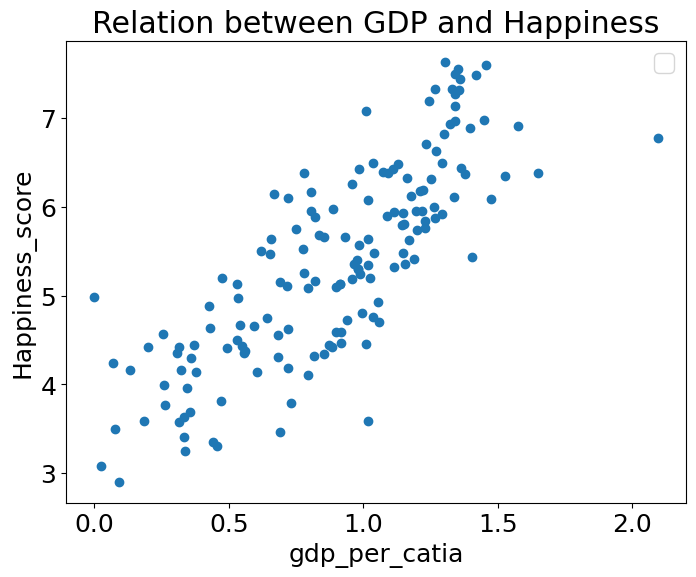

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(df['gdp_per_capita'], df['happiness_score'])
plt.xlabel("gdp_per_catia")
plt.ylabel("Happiness_score")
plt.title("Relation between GDP and Happiness")
plt.legend()
plt.show()


In [30]:
df.dtypes

overall_rank                 int64
country                     object
happiness_score            float64
gdp_per_capita             float64
social_support             float64
healthy_life_expectancy    float64
freedom_of_choice          float64
generosity                 float64
corruption_perception      float64
Region                      object
dtype: object

In [31]:
features = df.select_dtypes(include=['float64','int64'])
y=features.pop('happiness_score')
X = features.drop(columns=['overall_rank'])
labels = X.columns
labels

Index(['gdp_per_capita', 'social_support', 'healthy_life_expectancy',
       'freedom_of_choice', 'generosity', 'corruption_perception'],
      dtype='object')

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [33]:
from pca import pca
model = pca()
results = model.fit_transform(X,col_labels=labels)


[04-01-2026 17:49:06] [pca.pca] [INFO] Row labels are auto-completed.
[04-01-2026 17:49:06] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 6 columns of the input data.
[04-01-2026 17:49:06] [pca.pca] [INFO] Fit using PCA.
[04-01-2026 17:49:06] [pca.pca] [INFO] Compute loadings and PCs.
[04-01-2026 17:49:06] [pca.pca] [INFO] Compute explained variance.
[04-01-2026 17:49:06] [pca.pca] [INFO] The top 5 principal component(s) explains >= 95.00% of the explained variance.
[04-01-2026 17:49:06] [pca.pca] [INFO] The PCA reduction is performed on 6 variables (columns) of the input dataframe.
[04-01-2026 17:49:06] [pca.pca] [INFO] Fit using PCA.
[04-01-2026 17:49:06] [pca.pca] [INFO] Compute loadings and PCs.
[04-01-2026 17:49:06] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[5]
[04-01-2026 17:49:06] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[04-01-2026 17:49:06]

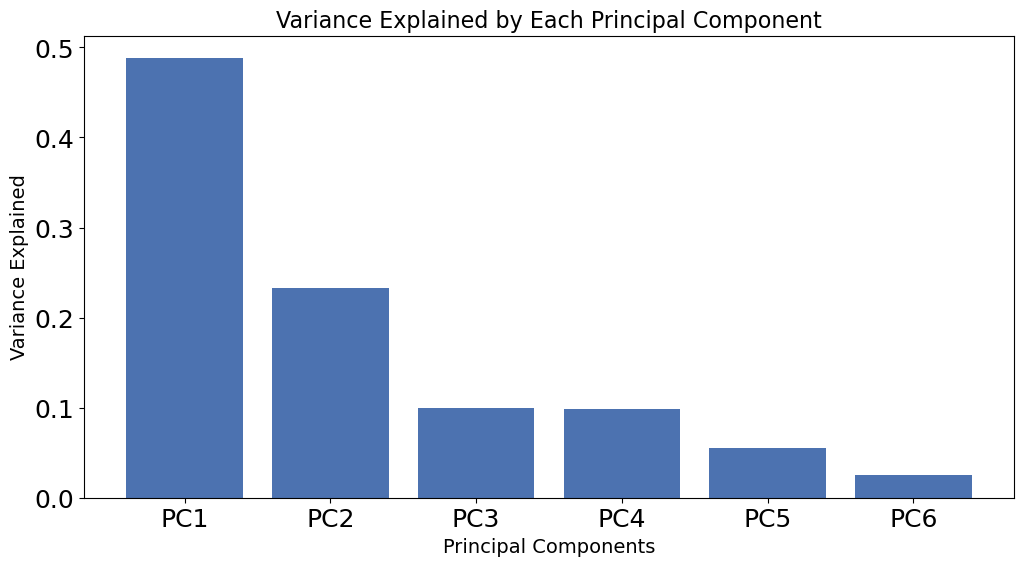

In [34]:

explained_var_ratio = results['variance_ratio']  


n_pcs = len(explained_var_ratio)
pcs = ['PC'+str(i+1) for i in range(n_pcs)]

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(pcs, explained_var_ratio, color='#4C72B0')



# Labels and title
plt.xlabel('Principal Components', fontsize=14)
plt.ylabel('Variance Explained', fontsize=14)
plt.title('Variance Explained by Each Principal Component', fontsize=16)



plt.xticks(pcs)

plt.show()


[04-01-2026 17:49:06] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[scatterd] >INFO> Create scatterplot


(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': 'PCA Biplot'}, xlabel='PC1 (48.8% expl.var)', ylabel='PC2 (23.2% expl.var)'>)

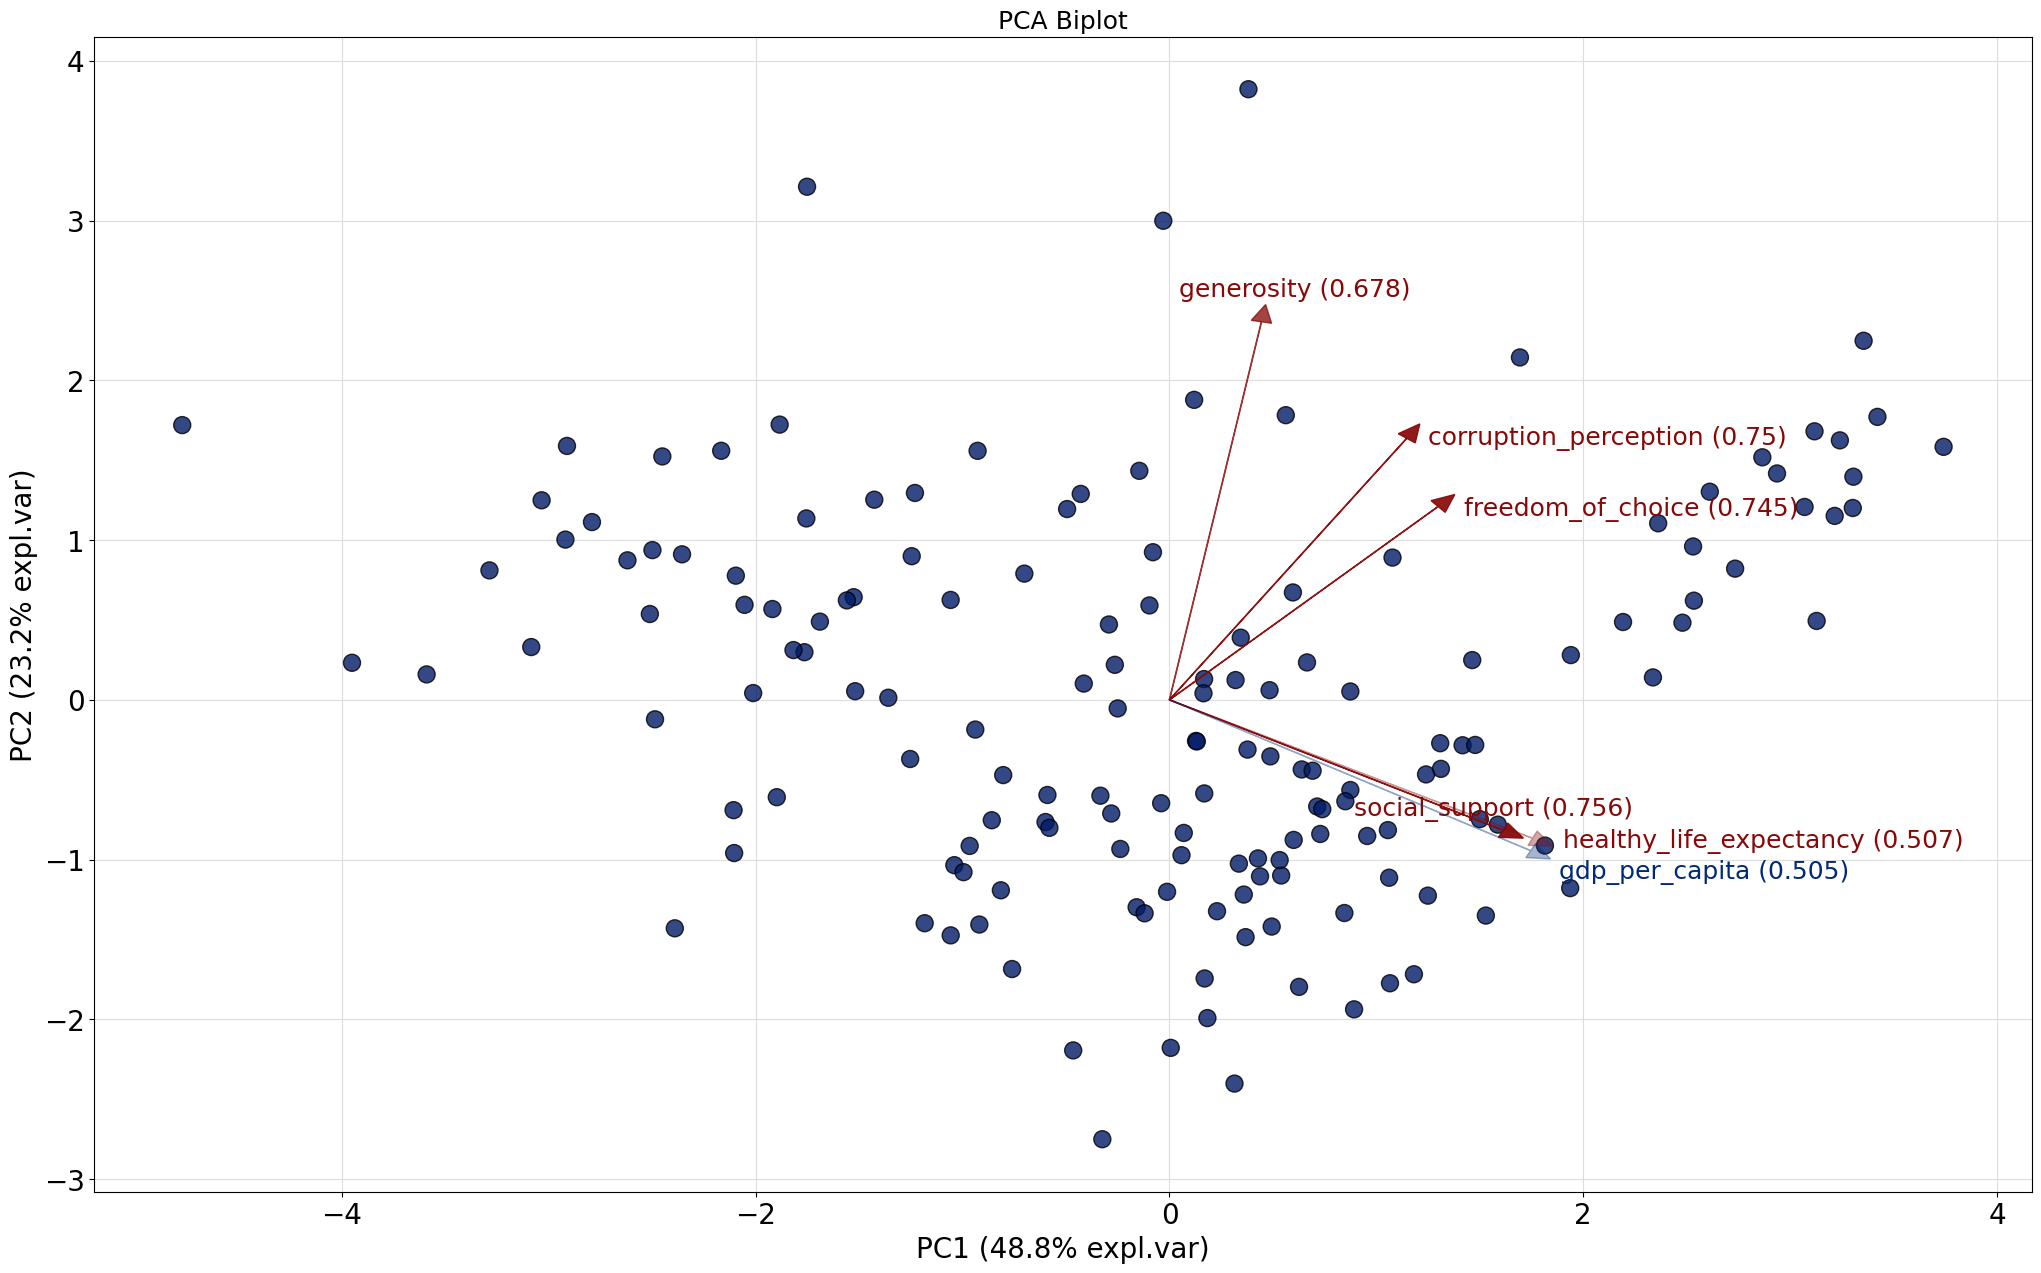

In [35]:
model.biplot(title='PCA Biplot', legend=False)

In [36]:
#explained variance by each pca component
pd.DataFrame({
    'PCA Component': [f'PC{i+1}' for i in range(len(model.results['variance_ratio']))],
    'Explained_Variance': model.results['variance_ratio'],
    'Cumulative': model.results['explained_var']
})



,PCA Component,Explained_Variance,Cumulative
0,PC1,0.488578,0.488578
1,PC2,0.232971,0.721549
2,PC3,0.099517,0.821066
3,PC4,0.098195,0.919261
4,PC5,0.055056,0.974317
5,PC6,0.025683,1.000000


In [37]:
model.results['topfeat']

,PC,feature,loading,type
0,PC1,healthy_life_expectancy,0.507478,best
1,PC2,generosity,0.677582,best
2,PC3,freedom_of_choice,0.744680,best
3,PC4,corruption_perception,0.749989,best
4,PC5,social_support,0.756395,best
5,PC1,gdp_per_capita,0.504522,weak


In [38]:
# loadings[['PC1','PC2']]

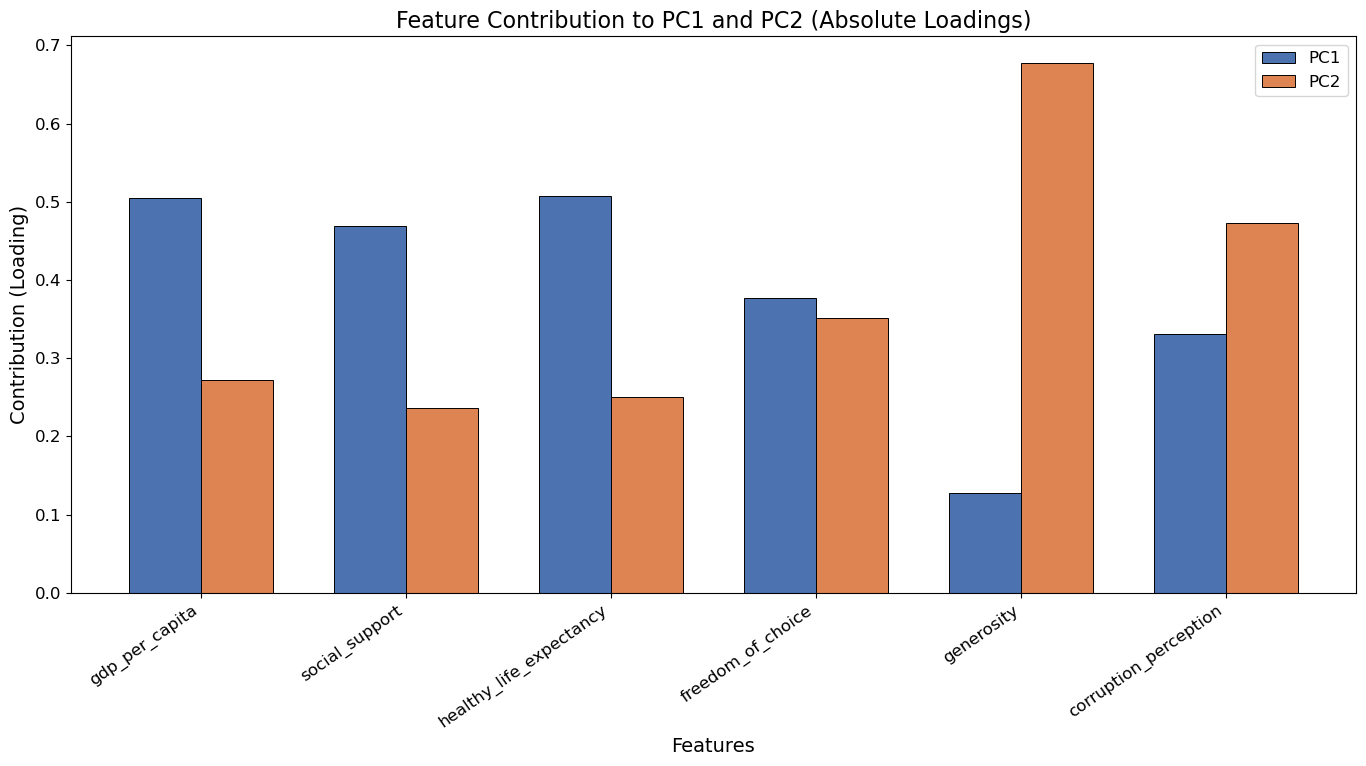

In [39]:
# Loadings from PCA
loadings = model.results['loadings'].T
features = loadings.index
x = np.arange(len(features))
width = 0.35
fig, ax = plt.subplots(figsize=(14,8))

# Plot bars with rounded edges
bars_pc1 = ax.bar(x - width/2, loadings['PC1'].abs(), width, label='PC1', color='#4C72B0', edgecolor='black', linewidth=0.7)
bars_pc2 = ax.bar(x + width/2, loadings['PC2'].abs(), width, label='PC2', color='#DD8452', edgecolor='black', linewidth=0.7)


ax.set_ylabel('Contribution (Loading)', fontsize=14)
ax.set_xlabel('Features', fontsize=14)
ax.set_title('Feature Contribution to PC1 and PC2 (Absolute Loadings)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=35, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)


ax.legend(fontsize=12)


plt.tight_layout()
plt.show()


Global happiness is structured by multiple dimensions, with economic development as the primary axis and institutional–social factors as a secondary but important dimension.

PC1 seems to capture the overall socio-economic and health well-being of a country. Higher values of PC1 correspond to countries with higher GDP, better life expectancy, stronger social support, and lower perceived corruption, which are all positively associated with happiness.

Strong positive contributors:
- gdp_per_capita (0.505)
- healthy_life_expectancy (0.507)
- social_support (0.468)

These three factors are highly correlated and form a “material and health well-being” cluster. Countries with higher GDP, better health, and stronger social support naturally tend to have higher happiness scores.
Key insight: Wealth, health, and social infrastructure reinforce each other—improvements in one often accompany improvements in the others.

PC2 represents a more social/psychological dimension of happiness. High values of PC2 are associated with countries where generosity, perceived freedom, and lower corruption stand out, even if GDP and life expectancy are lower. In contrast, countries with high GDP and health might have lower PC2 if generosity or freedom are weaker.

Strong contributors:

- generosity (0.678)

- corruption_perception (0.473)

- freedom_of_choice (0.352)

These factors are less about material well-being and more about social norms, ethics, and personal freedoms. High generosity, low perceived corruption, and freedom tend to go together as a “social-psychological well-being” dimension.

Key insight: Countries may be wealthy (high PC1) but low on PC2 if they lack generosity or freedom. These factors reflect happiness in a different, non-material sense.

In [40]:
# Assuming df has columns: 'country' and 'happiness_score'
top5_countries = df.sort_values('happiness_score', ascending=False).head(5)
print(top5_countries)


   overall_rank      country  happiness_score  gdp_per_capita  social_support  \
0             1      Finland            7.632           1.305           1.592   
1             2       Norway            7.594           1.456           1.582   
2             3      Denmark            7.555           1.351           1.590   
3             4      Iceland            7.495           1.343           1.644   
4             5  Switzerland            7.487           1.420           1.549   

   healthy_life_expectancy  freedom_of_choice  generosity  \
0                    0.874              0.681       0.202   
1                    0.861              0.686       0.286   
2                    0.868              0.683       0.284   
3                    0.914              0.677       0.353   
4                    0.927              0.660       0.256   

   corruption_perception          Region  
0                  0.393  Western Europe  
1                  0.340  Western Europe  
2                

In [41]:
pca_scores = results['PC']  

# Step 1: Copy the top 5 countries dataframe (with happiness scores)
top5_df = top5_countries[['country','happiness_score']].copy()
top5_df[['PC1', 'PC2']] = pca_scores.loc[top5_df.index, ['PC1', 'PC2']]


# Step 4: Show the result
top5_df

,country,happiness_score,PC1,PC2
0,Finland,7.632,3.214870,1.151421
1,Norway,7.594,3.305339,1.396784
2,Denmark,7.555,3.421553,1.771251
3,Iceland,7.495,2.733791,0.821269
4,Switzerland,7.487,3.302394,1.200969


Economic/health well-being is a strong predictor of high happiness among top countries.

Social/psychological factors help differentiate countries with similar material wealth.

The PCA shows that both dimensions are important, but for the top happiest countries, PC1 (material/health) dominates.

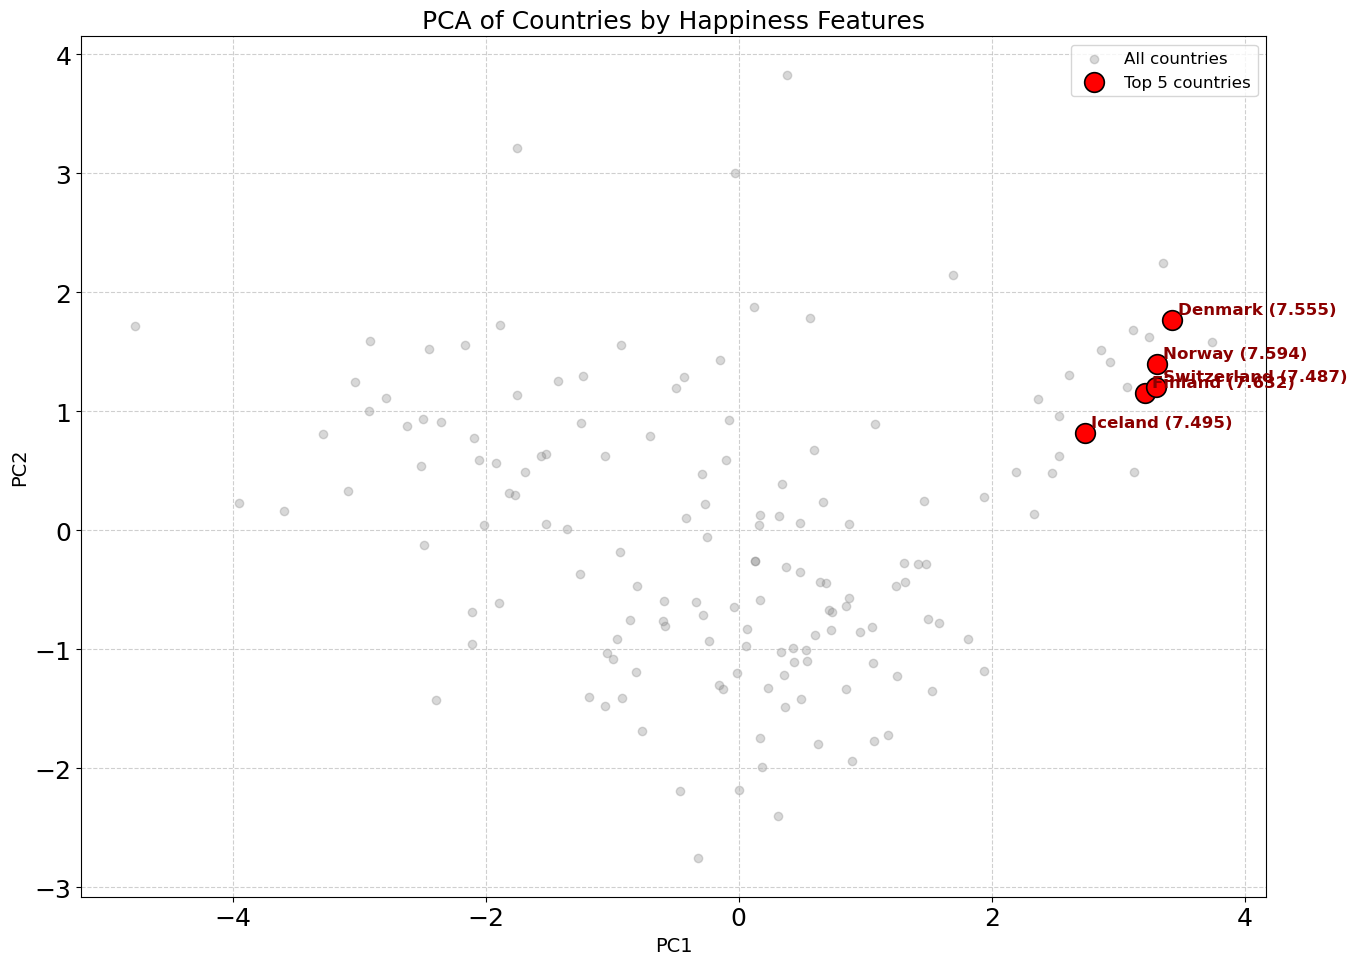

In [42]:


# Figure size and style
plt.figure(figsize=(14,10))


# Scatter all countries in light gray
plt.scatter(results['PC']['PC1'], results['PC']['PC2'], 
            alpha=0.3, color='gray', label='All countries')

# Highlight top 5 countries in red
plt.scatter(top5_df['PC1'], top5_df['PC2'], 
            color='red', label='Top 5 countries', s=200, edgecolor='black', linewidth=1.2)

# Annotate each top 5 country with name + happiness score
for i, row in top5_df.iterrows():
    country_name = row['country']
    score = row['happiness_score']
    plt.text(row['PC1'] + 0.05, row['PC2'] + 0.05, f"{country_name} ({score})", 
             fontsize=12, fontweight='bold', color='darkred')

# Axis labels and title with bigger fonts
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.title('PCA of Countries by Happiness Features', fontsize=18)

# Legend with larger font
plt.legend(fontsize=12)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


In [43]:
pca_scores_with_happiness = pca_scores[['PC1', 'PC2']].copy()
pca_scores_with_happiness['happiness_score'] = df['happiness_score']
pca_scores_with_happiness['country']=df['country']

# Top 5 countries by PC1
top5_by_pc1 = pca_scores_with_happiness.sort_values(by='PC1', ascending=False).head(5)
print("Top 5 countries by PC1:")
top5_by_pc1


Top 5 countries by PC1:


,PC1,PC2,happiness_score,country
33,3.741241,1.583647,6.343,Singapore
2,3.421553,1.771251,7.555,Denmark
7,3.354731,2.247588,7.324,New Zealand
1,3.305339,1.396784,7.594,Norway
4,3.302394,1.200969,7.487,Switzerland


In [44]:
# Top 5 countries by PC2
top5_by_pc2 = pca_scores_with_happiness.sort_values(by='PC2', ascending=False).head(5)
print("Top 5 countries by PC2:")
top5_by_pc2

Top 5 countries by PC2:


,PC1,PC2,happiness_score,country
129,0.381777,3.822219,4.308,Myanmar
97,-1.751452,3.211842,4.982,Somalia
150,-0.029708,2.998874,3.408,Rwanda
7,3.354731,2.247588,7.324,New Zealand
43,1.693869,2.143325,6.096,Uzbekistan


High PC1 values correspond to countries with strong economic and health factors: GDP per capita, life expectancy, social support.

Happiness scores are mostly high when pc1 is high, but note Singapore (6.343) has moderate happiness despite very high PC1 → indicates that material well-being alone doesn’t guarantee the highest happiness.


High PC2 values correspond to countries with strong social/psychological factors: generosity, freedom, low corruption perception.

Interesting cases:

Myanmar, Somalia, Rwanda → very high PC2 but low happiness scores → suggests that social/psychological factors alone cannot fully explain happiness if material/health factors are very low (low PC1).

New Zealand → high in both PC1 and PC2, leading to high overall happiness.

Happiness is multidimensional.

PC1 and PC2 help explain why countries with similar material wealth can have different happiness scores, and vice versa.

The PCA shows that economic/health and social/psychological factors are complementary, and the happiest countries excel in both dimensions.

In [45]:
df_pca = results['PC'].copy()

df_pca['Region'] = df['Region']

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,Region
0,3.214870,1.151421,0.533759,1.428027,0.703063,Western Europe
1,3.305339,1.396784,-0.023325,0.677455,0.364396,Western Europe
2,3.421553,1.771251,0.049532,1.182789,0.683827,Western Europe
3,2.733791,0.821269,-0.465820,-1.290032,-0.159553,Western Europe
4,3.302394,1.200969,-0.016332,1.037936,0.330269,Western Europe


### Are countries from certain regions characterized by similar combinations of economic, social, and institutional factors? 


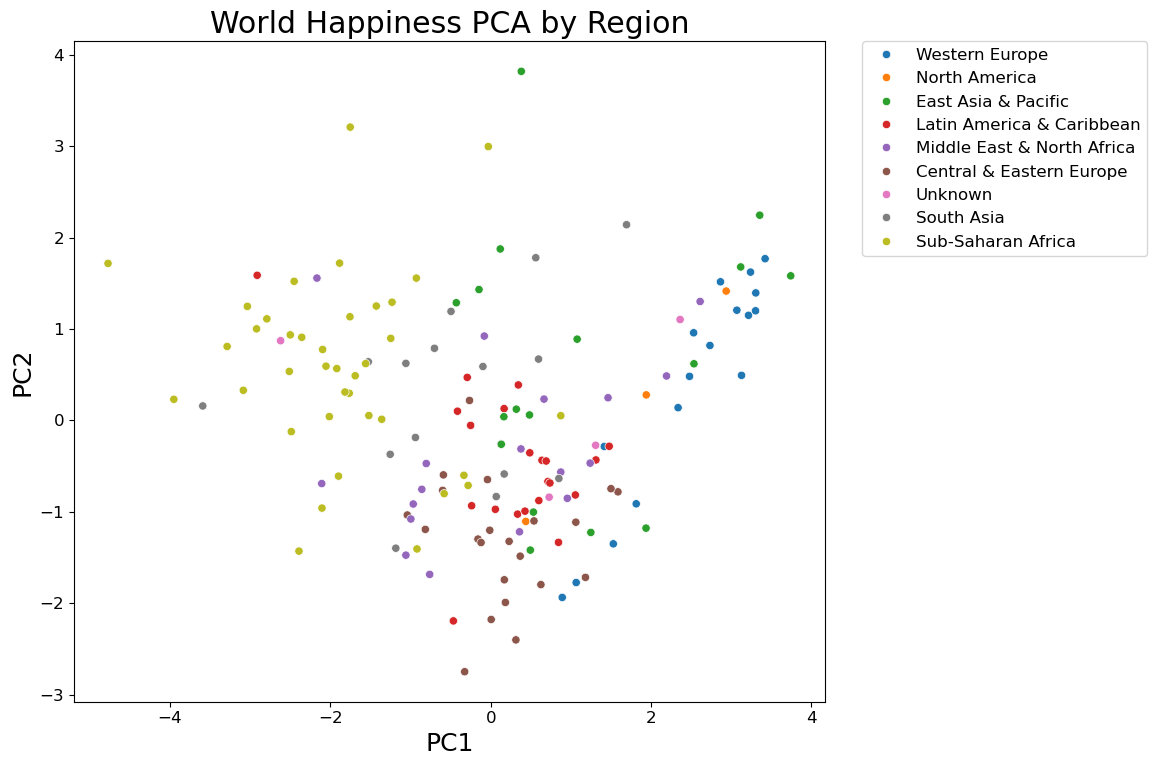

In [62]:
plt.figure(figsize=(12, 8))

sns.scatterplot(x='PC1', y='PC2', data=df_pca, hue='Region')

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=12, title_fontsize=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.title('World Happiness PCA by Region')

plt.tight_layout()
plt.show()

In [68]:
df_pca['Country'] = df['country']

df_pca

,PC1,PC2,PC3,PC4,PC5,Region,Country
0,3.214870,1.151421,0.533759,1.428027,0.703063,Western Europe,Finland
1,3.305339,1.396784,-0.023325,0.677455,0.364396,Western Europe,Norway
2,3.421553,1.771251,0.049532,1.182789,0.683827,Western Europe,Denmark
3,2.733791,0.821269,-0.465820,-1.290032,-0.159553,Western Europe,Iceland
4,3.302394,1.200969,-0.016332,1.037936,0.330269,Western Europe,Switzerland
...,...,...,...,...,...,...,...
151,-2.106542,-0.690422,0.088588,0.400585,0.661433,Middle East & North Africa,Yemen
152,-1.230050,1.294995,0.041869,-0.472259,-0.055917,Sub-Saharan Africa,Tanzania
153,-3.286320,0.810360,-1.195079,0.824658,0.163428,Sub-Saharan Africa,South Sudan
154,-4.771123,1.719800,-0.060247,0.636818,-1.491774,Sub-Saharan Africa,Central African Republic


In [70]:
df_pca[(df_pca['PC1'] > 1) & (df_pca['Region'] == 'Latin America & Caribbean')]

,PC1,PC2,PC3,PC4,PC5,Region,Country
12,1.311907,-0.431976,0.794996,-0.434895,-0.176592,Latin America & Caribbean,Costa Rica
26,1.055680,-0.815269,0.719344,-0.548347,-0.265449,Latin America & Caribbean,Panama
30,1.477608,-0.282245,0.844172,0.071204,0.030918,Latin America & Caribbean,Uruguay


In [72]:
df_pca[(df_pca['PC2'] > 1) & (df_pca['Region'] == 'South Asia')]

,PC1,PC2,PC3,PC4,PC5,Region,Country
43,1.693869,2.143325,0.603377,-0.496510,0.930190,South Asia,Uzbekistan
96,0.562259,1.781917,-0.490517,-0.722205,0.423838,South Asia,Bhutan
100,-0.494669,1.194302,-0.027045,-1.112764,0.156473,South Asia,Nepal
